# Source-Target CRP

> Compute availability-adjusted transition probabilities from source-item valence to next-recall target valence.

This template reproduces the Cohen/Kahana-style source-target valence plot using the trial-local `valence` field in the stored HDF5 dataset. The denominator is the number of currently available targets in the plotted target condition, not a same/different bin indicator.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import warnings
from tabulate import tabulate
from jaxcmr.analyses.source_target_crp import plot_source_target_crp, subject_source_target_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [ ]:
data_path = "data/CohenKahana2022_noELI.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['session'] >= 1"
source_field = "valence"
source_values = [-1, 0, 1]
source_labels = ["Negative", "Neutral", "Positive"]
target_field = "valence"
target_values = [-1, 0, 1]
target_labels = ["Recall i + 1 is Negative", "Recall i + 1 is Neutral", "Recall i + 1 is Positive"]
xlabel = "Valence of Recalled Item i"
ylabel = "Avail.-Adjusted Transition Prob."
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
data["_should_tabulate"] = data["recalls"] > 0
trial_mask = generate_trial_mask(data, trial_query)

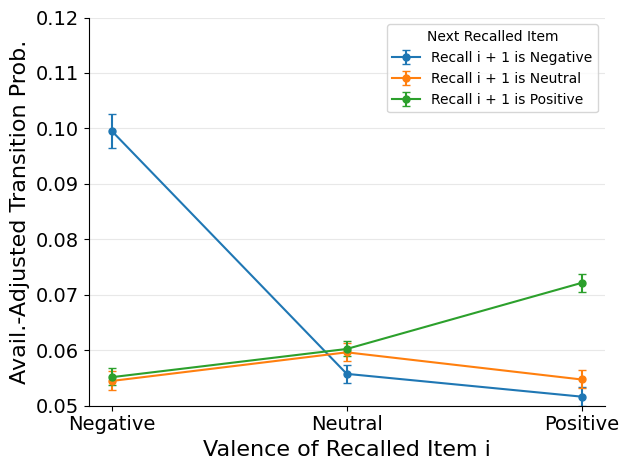

In [4]:
plot_source_target_crp(
    data,
    trial_mask,
    source_field=source_field,
    source_values=source_values,
    target_field=target_field,
    target_values=target_values,
    source_labels=source_labels,
    labels=target_labels,
    contrast_name="Next Recalled Item",
    xlabel=xlabel,
    ylabel=ylabel,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

In [5]:
subject_values = subject_source_target_crp(
    data,
    trial_mask,
    source_field=source_field,
    source_values=source_values,
    target_field=target_field,
    target_values=target_values,
)
rows = []
for source_index, source_label in enumerate(source_labels):
    for target_index, target_label in enumerate(target_labels):
        values = subject_values[:, source_index, target_index]
        valid = np.isfinite(values)
        rows.append([
            source_label,
            target_label.replace("Recall i + 1 is ", "Next "),
            np.nanmean(values),
            np.nanstd(values, ddof=1) / np.sqrt(valid.sum()),
            valid.sum(),
        ])
print(tabulate(rows, headers=["Source", "Target", "Mean", "SEM", "N"], floatfmt=".4f"))

Source    Target           Mean     SEM        N
--------  -------------  ------  ------  -------
Negative  Next Negative  0.0995  0.0016  97.0000
Negative  Next Neutral   0.0545  0.0009  97.0000
Negative  Next Positive  0.0552  0.0008  97.0000
Neutral   Next Negative  0.0557  0.0009  97.0000
Neutral   Next Neutral   0.0596  0.0008  97.0000
Neutral   Next Positive  0.0602  0.0007  97.0000
Positive  Next Negative  0.0516  0.0009  97.0000
Positive  Next Neutral   0.0547  0.0008  97.0000
Positive  Next Positive  0.0721  0.0008  97.0000


## Interpretation

The plot asks whether the next recalled item is preferentially drawn from a valence category after adjusting for how many unrecalled targets from that category are currently available. Same-valence emotional organization appears when the negative line is higher for negative source recalls and the positive line is higher for positive source recalls.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `source_field` / `source_values` — previous-recall condition shown on the x-axis.
- `target_field` / `target_values` — next-recall target conditions shown as separate lines.
- `source_labels` / `target_labels` — display labels for the plotted conditions.
- `confidence_level` — confidence level for subject-wise error bars.

The `_should_tabulate` mask is constructed in the load cell as `data["recalls"] > 0` (excludes padding and intrusions from scored transitions while valid recalls still update state).